<a href="https://colab.research.google.com/github/rashi-gundawar/Deep-Learning/blob/main/Assignments/Assignment05/Assignment05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement and compare RNN, LSTM, GRU models for sequence classification and analyse their performance using appropriate evaluation matrix.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Check GPU availability
print(
    "GPU available:",
    tf.config.list_physical_devices("GPU")
)

if tf.config.list_physical_devices("GPU"):
    print("Using GPU")
else:
    print("Using CPU")

GPU available: []
Using CPU


In [3]:
# Set model and training parameters
VOCAB_SIZE = 10000
MAX_LENGTH = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 3
SEED = 42

print("Vocabulary size:", VOCAB_SIZE)
print("Maximum sequence length:", MAX_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Vocabulary size: 10000
Maximum sequence length: 200
Embedding dimension: 128
Batch size: 64
Epochs: 3


In [4]:
# Load the IMDB movie review dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("First review length:", len(x_train[0]))
print("First review label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review length: 218
First review label: 1


In [5]:
# Pad all reviews to the same sequence length
x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)
x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [6]:
# Display sentiment class information
print(
    "Negative training reviews:",
    np.sum(y_train == 0)
)
print(
    "Positive training reviews:",
    np.sum(y_train == 1)
)
print("\nClass labels:")
print("0 = Negative")
print("1 = Positive")

Negative training reviews: 12500
Positive training reviews: 12500

Class labels:
0 = Negative
1 = Positive


In [7]:
# Build the Simple RNN model
def build_rnn_model():
    model = models.Sequential([
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        layers.SimpleRNN(
            64
        ),
        layers.Dense(
            64,
            activation="relu"
        ),
        layers.Dropout(
            0.4
        ),
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model
rnn_model = build_rnn_model()
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the Simple RNN model
rnn_history = rnn_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.5001 - loss: 0.6992 - val_accuracy: 0.5054 - val_loss: 0.6933
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.5482 - loss: 0.6834 - val_accuracy: 0.5002 - val_loss: 0.6959
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - accuracy: 0.6310 - loss: 0.5925 - val_accuracy: 0.5232 - val_loss: 0.7531


In [9]:
# Evaluate the Simple RNN model
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print(
    f"RNN Test Accuracy: {rnn_accuracy * 100:.2f}%"
)

RNN Test Accuracy: 51.68%


In [10]:
# Build the LSTM model
def build_lstm_model():
    model = models.Sequential([
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        layers.LSTM(
            64
        ),
        layers.Dense(
            64,
            activation="relu"
        ),
        layers.Dropout(
            0.4
        ),
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model
lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the LSTM model
lstm_history = lstm_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 270ms/step - accuracy: 0.5460 - loss: 0.6794 - val_accuracy: 0.5296 - val_loss: 0.7717
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 273ms/step - accuracy: 0.5823 - loss: 0.6597 - val_accuracy: 0.5694 - val_loss: 0.6762
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 279ms/step - accuracy: 0.6607 - loss: 0.6023 - val_accuracy: 0.5472 - val_loss: 0.6827


In [12]:
# Evaluate the LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print(
    f"LSTM Test Accuracy: {lstm_accuracy * 100:.2f}%"
)

LSTM Test Accuracy: 53.81%


In [13]:
# Build the GRU model
def build_gru_model():
    model = models.Sequential([
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM
        ),
        layers.GRU(
            64
        ),
        layers.Dense(
            64,
            activation="relu"
        ),
        layers.Dropout(
            0.4
        ),
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model
gru_model = build_gru_model()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the GRU model
gru_history = gru_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 289ms/step - accuracy: 0.5143 - loss: 0.6923 - val_accuracy: 0.5476 - val_loss: 0.6863
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 285ms/step - accuracy: 0.6019 - loss: 0.6405 - val_accuracy: 0.6134 - val_loss: 0.6711
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 301ms/step - accuracy: 0.8078 - loss: 0.4296 - val_accuracy: 0.8580 - val_loss: 0.3568


In [15]:
# Evaluate the GRU model
gru_loss, gru_accuracy = gru_model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print(
    f"GRU Test Accuracy: {gru_accuracy * 100:.2f}%"
)

GRU Test Accuracy: 83.98%


In [16]:
# Create a comparison table for model accuracy
results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU"
    ],
    "Accuracy (%)": [
        rnn_accuracy * 100,
        lstm_accuracy * 100,
        gru_accuracy * 100
    ]
})
print(results)

        Model  Accuracy (%)
0  Simple RNN     51.675999
1        LSTM     53.811997
2         GRU     83.980000


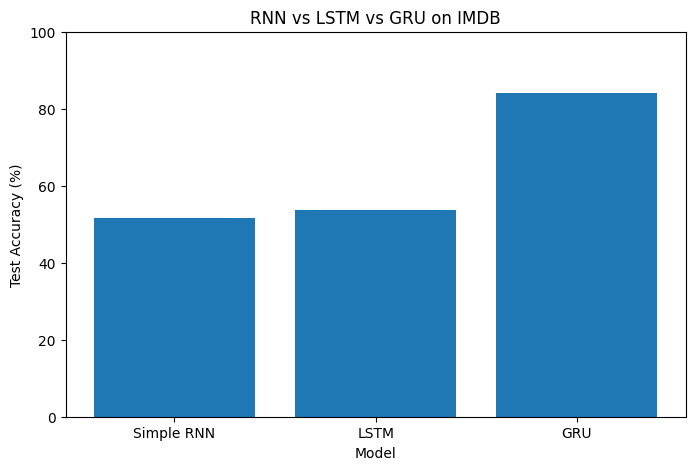

In [17]:
# Plot test accuracy of all three models
plt.figure(figsize=(8, 5))
plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title(
    "RNN vs LSTM vs GRU on IMDB"
)
plt.ylim(0, 100)
plt.show()

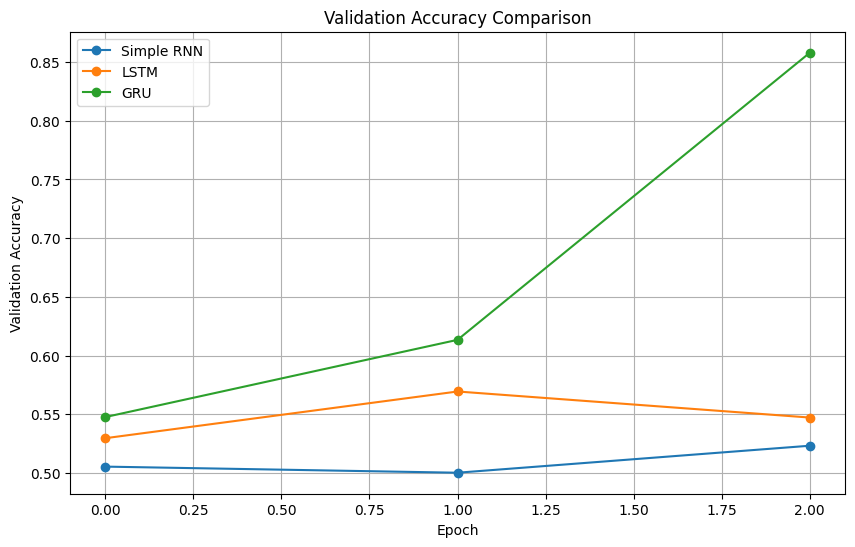

In [18]:
# Compare validation accuracy across epochs
plt.figure(figsize=(10, 6))
plt.plot(
    rnn_history.history["val_accuracy"],
    marker="o",
    label="Simple RNN"
)
plt.plot(
    lstm_history.history["val_accuracy"],
    marker="o",
    label="LSTM"
)
plt.plot(
    gru_history.history["val_accuracy"],
    marker="o",
    label="GRU"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(
    "Validation Accuracy Comparison"
)
plt.legend()
plt.grid()
plt.show()

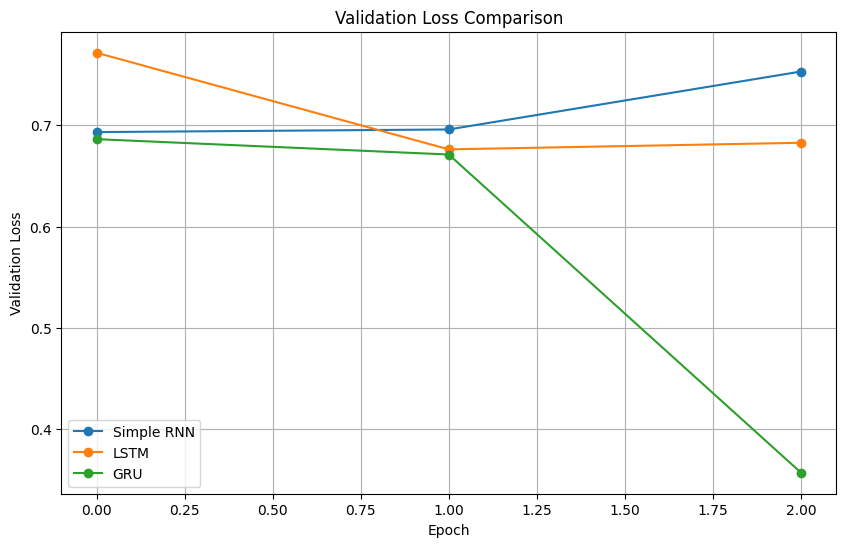

In [19]:
# Compare validation loss across epochs
plt.figure(figsize=(10, 6))
plt.plot(
    rnn_history.history["val_loss"],
    marker="o",
    label="Simple RNN"
)
plt.plot(
    lstm_history.history["val_loss"],
    marker="o",
    label="LSTM"
)
plt.plot(
    gru_history.history["val_loss"],
    marker="o",
    label="GRU"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss Comparison"
)
plt.legend()
plt.grid()
plt.show()

In [20]:
# Generate predictions from all three models
rnn_prob = rnn_model.predict(
    x_test,
    verbose=0
)
lstm_prob = lstm_model.predict(
    x_test,
    verbose=0
)
gru_prob = gru_model.predict(
    x_test,
    verbose=0
)
rnn_pred = (
    rnn_prob >= 0.5
).astype(int).flatten()
lstm_pred = (
    lstm_prob >= 0.5
).astype(int).flatten()
gru_pred = (
    gru_prob >= 0.5
).astype(int).flatten()

In [21]:
# Calculate accuracy, precision, recall and F1-score
model_predictions = {
    "Simple RNN": rnn_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred
}
comparison = []
for model_name, predictions in model_predictions.items():
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    comparison.append({
        "Model": model_name,
        "Accuracy (%)":
            accuracy * 100,
        "Precision (%)":
            precision * 100,
        "Recall (%)":
            recall * 100,
        "F1-Score (%)":
            f1 * 100
    })
comparison_df = pd.DataFrame(
    comparison
)
print(
    comparison_df.round(2)
)

        Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
0  Simple RNN         51.68          51.13       75.73         61.05
1        LSTM         53.81          55.57       38.02         45.15
2         GRU         83.98          87.97       78.72         83.09


In [22]:
# Display classification reports for each model
for model_name, predictions in model_predictions.items():
    print(
        "\n" + "=" * 60
    )
    print(model_name)
    print(
        "=" * 60
    )
    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Negative",
                "Positive"
            ],
            zero_division=0
        )
    )


Simple RNN
              precision    recall  f1-score   support

    Negative       0.53      0.28      0.36     12500
    Positive       0.51      0.76      0.61     12500

    accuracy                           0.52     25000
   macro avg       0.52      0.52      0.49     25000
weighted avg       0.52      0.52      0.49     25000


LSTM
              precision    recall  f1-score   support

    Negative       0.53      0.70      0.60     12500
    Positive       0.56      0.38      0.45     12500

    accuracy                           0.54     25000
   macro avg       0.54      0.54      0.53     25000
weighted avg       0.54      0.54      0.53     25000


GRU
              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85     12500
    Positive       0.88      0.79      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     250

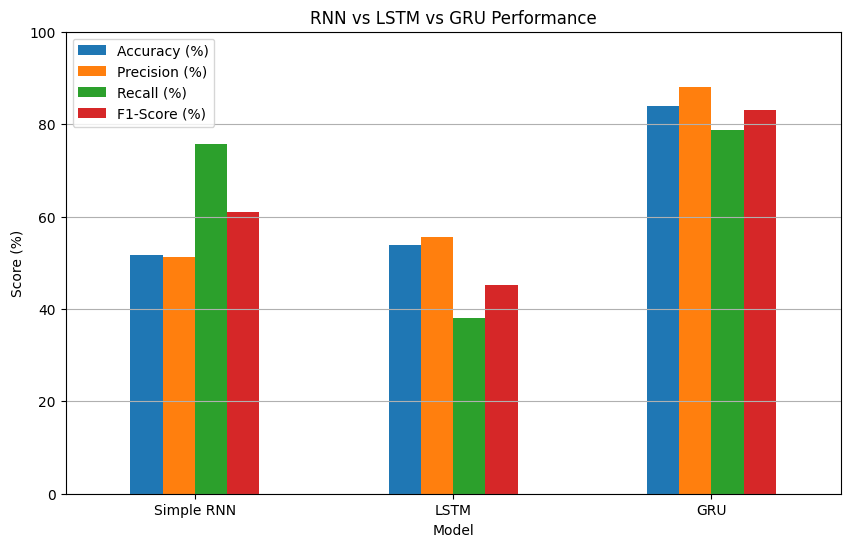

In [23]:
# Plot accuracy, precision, recall and F1-score
comparison_df.set_index(
    "Model"
)[
    [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.title(
    "RNN vs LSTM vs GRU Performance"
)
plt.ylim(0, 100)
plt.xticks(
    rotation=0
)
plt.grid(
    axis="y"
)
plt.show()

In [24]:
# Save the final comparison results
comparison_df.to_csv(
    "RNN_LSTM_GRU_IMDB_Results.csv",
    index=False
)
print(
    "Results saved successfully."
)

Results saved successfully.


In [25]:
# Display the final experiment summary

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(
    comparison_df.round(2)
)
print(
    "\nDataset: IMDB Movie Reviews"
)
print(
    "Task: Binary Sentiment Classification"
)
print(
    "Models: Simple RNN, LSTM, GRU"
)

FINAL RESULTS
        Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
0  Simple RNN         51.68          51.13       75.73         61.05
1        LSTM         53.81          55.57       38.02         45.15
2         GRU         83.98          87.97       78.72         83.09

Dataset: IMDB Movie Reviews
Task: Binary Sentiment Classification
Models: Simple RNN, LSTM, GRU
